In [49]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../../..")))

from src.predictor import ShorelinePredictor
from src.data_processing.dataset_loader import CoastData
from src.data_processing.crop import crop, apply_masks, merge_image_with_mask, merge_masks

import cv2

In [63]:
def extract_mask(image_path: str, shoreline_coords: dict, land_side: str = "l") -> np.ndarray:
        if land_side not in ["l", "r"]:
            raise ValueError("land_side must be 'l' or 'r'")
        # print(shoreline_coords)
        img = cv2.imread(image_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        mask = np.zeros(img.shape[:2], dtype=np.uint8)

        # 1. Extract the ROI from the input image
        height, width, _ = img.shape

        points = []
        for u, v in zip(shoreline_coords["u"], shoreline_coords["v"]):
            points.append((int(u), height - int(v)))

        cv2.polylines(mask, [np.array(points)], isClosed=False, color=255, thickness=1)


        ys = [p[1] for p in points]
        # y_min = max(min(ys) - 50, 0)
        # y_max = min(max(ys) + 50, height - 1)
        y_min = max(min(ys), 0)
        y_max = min(max(ys), height - 1)

        
        # xs = [p[0] for p in points]
        # x_min = min(xs)
        # x_max = max(xs)
        x_min = 0
        x_max = width - 1

        # for x rows, and remove full white rows
        for x in range(0, x_max):
            col_pixels = img[y_min:y_max + 1, x, :]
            count = np.count_nonzero(col_pixels == 255)
            if count >= col_pixels.shape[0]*0.75:
                x_min += 1
            else:
                break

        for x in range(x_max, 0, -1):
            col_pixels = img[y_min:y_max + 1, x, :]
            count = np.count_nonzero(col_pixels == 255)
            if count >= col_pixels.shape[0]*0.75:
                x_max -= 1
            else:
                break

        crop_coords = ((y_min, x_min), (y_max, x_max))

        aux_mask = crop(mask, crop_coords[0], crop_coords[1])

        for row in range(aux_mask.shape[0]):
            for col in range(aux_mask.shape[1]):
                if aux_mask[row, col] == 255:
                    if land_side == "l":
                        aux_mask[row, :col] = 1
                        aux_mask[row, col:] = 2
                    else:
                        aux_mask[row, :col] = 2
                        aux_mask[row, col:] = 1
                    break

        mask = np.zeros(img.shape[:2], dtype=np.uint8)
        
        mask = merge_masks(mask, aux_mask, crop_coords[0], crop_coords[1])

        return mask

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List

def create_error_heatmap(predictions: List[np.ndarray], 
                         ground_truths: List[np.ndarray]) -> np.ndarray:
    if not predictions or not ground_truths:
        raise ValueError("Input lists cannot be empty.")
    
    if len(predictions) != len(ground_truths):
        raise ValueError("The number of predictions must match the number of ground truths.")

    # Get the shape from the first mask and initialize the accumulator
    first_mask_shape = ground_truths[0].shape
    total_error_map = np.zeros(first_mask_shape, dtype=np.float32)
    num_images = len(ground_truths)

    for pred_mask, true_mask in zip(predictions, ground_truths):
        if pred_mask.shape != first_mask_shape or true_mask.shape != first_mask_shape:
            raise ValueError("All masks must have the same dimensions.")
            
        error_map = (pred_mask != true_mask).astype(np.uint8)
        
        total_error_map += error_map

    average_error_heatmap = total_error_map / num_images
    
    return average_error_heatmap

In [ ]:
data_path = os.path.abspath(os.path.join(os.getcwd(), "../../../data/SCLabels_oblique_registered_v1.0.0/"))

stations = {
    "samarador": {
        "land_side": "r"
    },
    "arenaldentem": {
        "land_side": "l"
    }, 
    "cadiz": {
        "land_side": "l"
    }
}
station_name = "cadiz"
coast_data = CoastData(data_path, name=station_name)
data = coast_data.split_data(get_coords=True)

CoastData: cadiz - 946 images
Coast: cadiz, Total size: 946


In [98]:
model_weight_path = os.path.abspath(os.path.join(os.getcwd(), "../../../artifacts/", "2025-10-02-10-54-16_2_classes_256x1024_b24/models/best_model.pth"))

model = "DeepLabV3"
num_classes = 2

predictor = ShorelinePredictor(model, model_weight_path, num_classes)

In [106]:
split = "test"
predictions = []
masks = []

for i in range(len(data[split]['images'])):
    img_path = data[split]['images'][i]
    shoreline_coords = data[split]['masks'][i]
    output = predictor.predict_oblique_with_coords(img_path, shoreline_coords=shoreline_coords, patch_size=(256, 1024), stride=(128, 512))
    predictions.append(output["predicted_mask"])
    
    mask = extract_mask(img_path, shoreline_coords, land_side=stations[station_name]['land_side'])
    masks.append(mask)
    if i % 10 == 0:
        print(f"Processed {i+1}/{len(data[split]['images'])} images.")

Processed 1/95 images.
Processed 11/95 images.
Processed 21/95 images.
Processed 31/95 images.
Processed 41/95 images.
Processed 51/95 images.
Processed 61/95 images.
Processed 71/95 images.
Processed 81/95 images.
Processed 91/95 images.


In [107]:
error_heatmap = create_error_heatmap(predictions=predictions, ground_truths=masks)

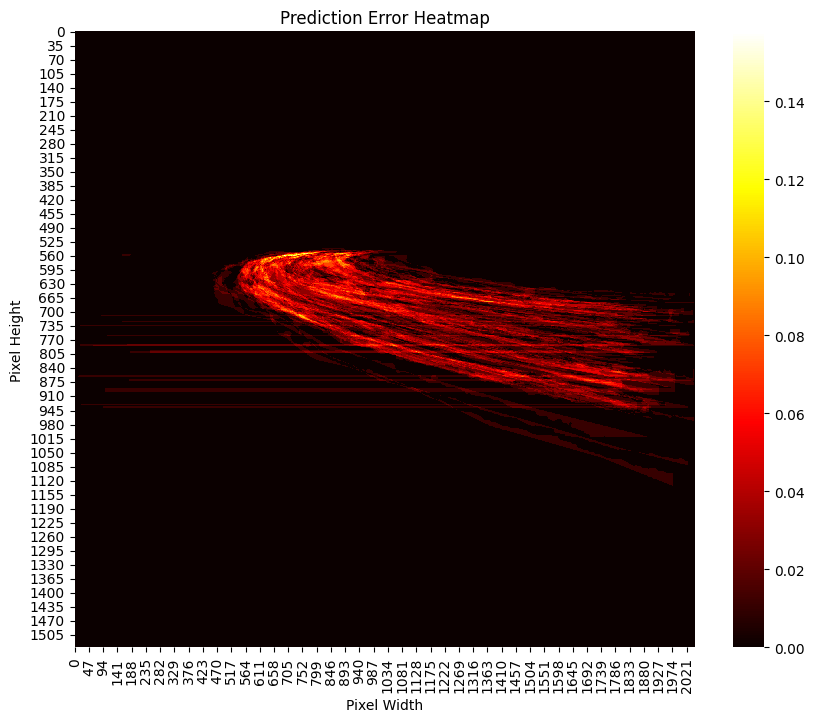

Maximum error frequency in a single pixel: 0.16
Average error frequency across all pixels: 0.00


In [108]:
plt.figure(figsize=(10, 8))
sns.heatmap(error_heatmap, cmap='hot')

plt.title('Prediction Error Heatmap')
plt.xlabel('Pixel Width')
plt.ylabel('Pixel Height')
plt.show()

# You can also check the values
print(f"Maximum error frequency in a single pixel: {np.max(error_heatmap):.2f}")
print(f"Average error frequency across all pixels: {np.mean(error_heatmap):.2f}")